In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)       
df.head()  

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
print(df['TotalCharges'].isnull().sum()) 

11


In [10]:
# These 11 customers have tenure=0, so they just joined — fill with MonthlyCharges
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])
# Verify it's clean
print(df['TotalCharges'].isnull().sum())  # Should show 0
print(df['TotalCharges'].dtype)           # Should show float64

0
float64


In [11]:
# Drop customerID — it's just an ID, no predictive value
df.drop(columns=['customerID'], inplace=True)

# Encode target: Yes → 1, No → 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(df.shape)        # Should be (7043, 20)
print(df['Churn'].value_counts())

(7043, 20)
Churn
0    5174
1    1869
Name: count, dtype: int64


In [12]:
# 1. Tenure Groups — how long has the customer been with us?
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['New (0-12m)', 'Growing (1-2y)', 'Established (2-4y)', 'Loyal (4+y)']
)

# 2. How many services does this customer use?
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServiceCount'] = df[service_cols].apply(
    lambda row: sum(1 for v in row if v == 'Yes'), axis=1
)

# 3. Customer Lifetime Value — simple but powerful
df['CLV'] = df['MonthlyCharges'] * 24  # assumed 24 remaining months

# 4. Contract risk — encode business logic directly
df['ContractRiskScore'] = df['Contract'].map({
    'Month-to-month': 3,
    'One year': 2,
    'Two year': 1
})

print(df[['tenure', 'TenureGroup', 'ServiceCount', 'CLV', 'ContractRiskScore']].head(10))
print(f"\nNew shape: {df.shape}")

   tenure         TenureGroup  ServiceCount     CLV  ContractRiskScore
0       1         New (0-12m)             1   716.4                  3
1      34  Established (2-4y)             3  1366.8                  2
2       2         New (0-12m)             3  1292.4                  3
3      45  Established (2-4y)             3  1015.2                  2
4       2         New (0-12m)             1  1696.8                  3
5       8         New (0-12m)             4  2391.6                  3
6      22      Growing (1-2y)             3  2138.4                  3
7      10         New (0-12m)             1   714.0                  3
8      28  Established (2-4y)             5  2515.2                  3
9      62         Loyal (4+y)             3  1347.6                  2

New shape: (7043, 24)


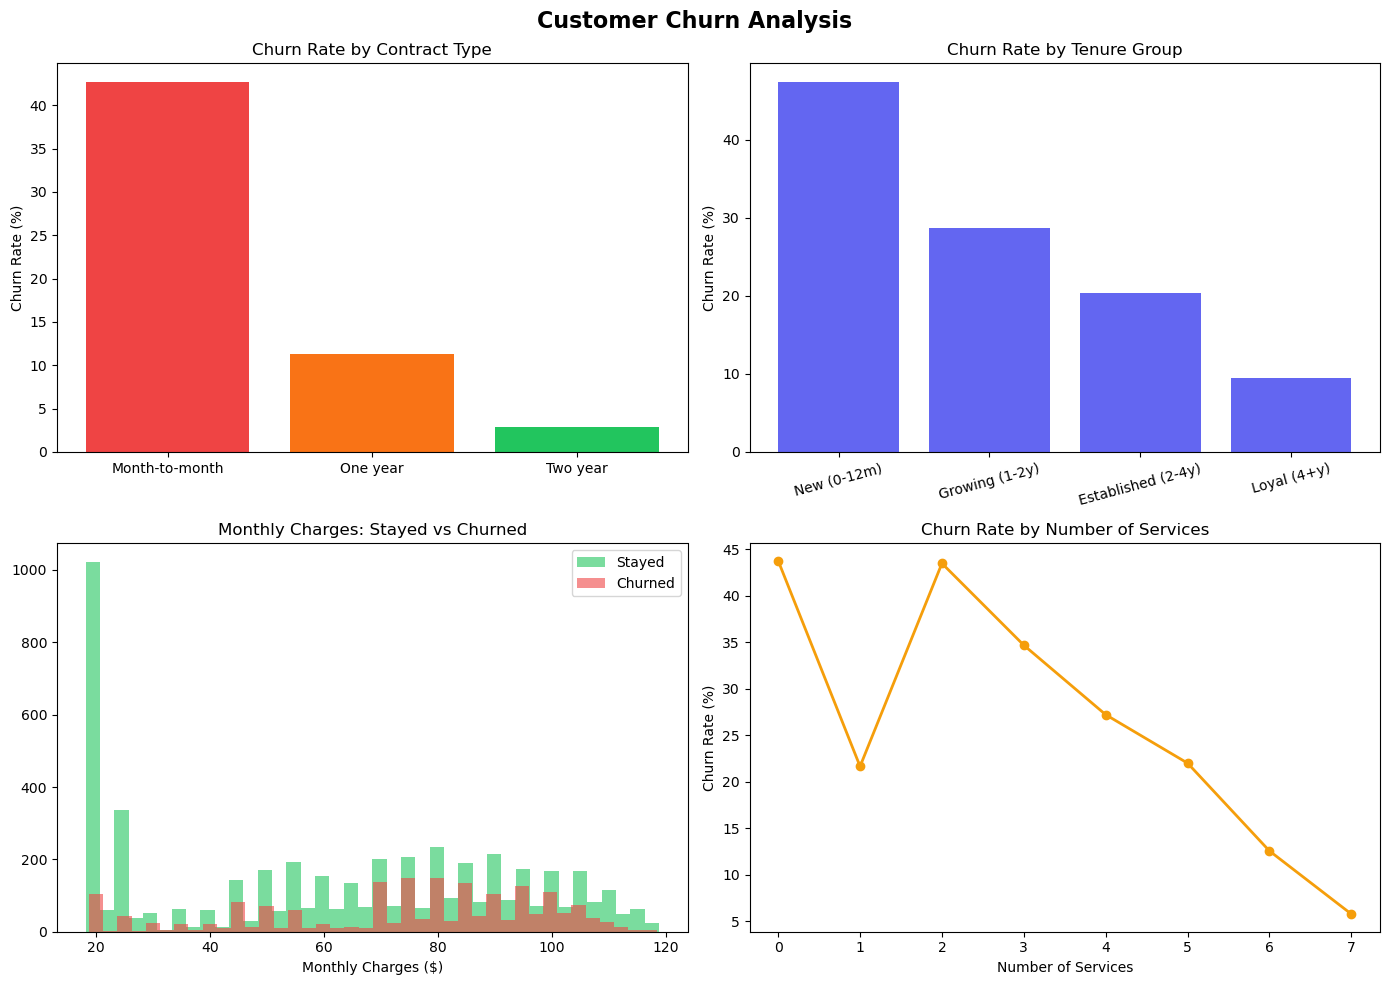

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Churn Analysis', fontsize=16, fontweight='bold')

# 1. Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
axes[0,0].bar(contract_churn.index, contract_churn.values * 100, color=['#ef4444','#f97316','#22c55e'])
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_ylabel('Churn Rate (%)')

# 2. Churn by Tenure Group
tenure_churn = df.groupby('TenureGroup', observed=True)['Churn'].mean()
axes[0,1].bar(tenure_churn.index, tenure_churn.values * 100, color='#6366f1')
axes[0,1].set_title('Churn Rate by Tenure Group')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Monthly Charges distribution
axes[1,0].hist(df[df['Churn']==0]['MonthlyCharges'], bins=40, alpha=0.6, label='Stayed', color='#22c55e')
axes[1,0].hist(df[df['Churn']==1]['MonthlyCharges'], bins=40, alpha=0.6, label='Churned', color='#ef4444')
axes[1,0].set_title('Monthly Charges: Stayed vs Churned')
axes[1,0].set_xlabel('Monthly Charges ($)')
axes[1,0].legend()

# 4. Churn by Service Count
service_churn = df.groupby('ServiceCount')['Churn'].mean()
axes[1,1].plot(service_churn.index, service_churn.values * 100, marker='o', color='#f59e0b', linewidth=2)
axes[1,1].set_title('Churn Rate by Number of Services')
axes[1,1].set_xlabel('Number of Services')
axes[1,1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print(df.groupby(['Contract', 'TenureGroup'], observed=True)['Churn'].mean().unstack())

TenureGroup     New (0-12m)  Growing (1-2y)  Established (2-4y)  Loyal (4+y)
Contract                                                                    
Month-to-month     0.513541        0.377205            0.329177     0.260234
One year           0.104839        0.081218            0.106178     0.129338
Two year           0.000000        0.000000            0.021898     0.033254


In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Step 5a: Encode all text columns
df_ml = df.copy()
df_ml = df_ml.drop(columns=['TenureGroup'])  # already captured in tenure + ContractRiskScore

cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
print("Columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

Columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
# Step 5b: Split into features and target
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 5634
Test samples:     1409


In [17]:
# Step 5c: Train Logistic Regression (always start simple)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC Score: 0.8400


C:\Users\Rishil\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Scale numerical features — fixes the convergence warning too
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain Logistic Regression on scaled data
lr_scaled = LogisticRegression(max_iter=1000, random_state=42)
lr_scaled.fit(X_train_scaled, y_train)
y_pred_lr = lr_scaled.predict(X_test_scaled)
y_prob_lr = lr_scaled.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression (Scaled) ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== Logistic Regression (Scaled) ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8402


In [19]:
# Now try XGBoost — handles imbalance better
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=5174/1869,  # handles class imbalance — ratio of No:Yes
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)  # XGBoost doesn't need scaling
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8394


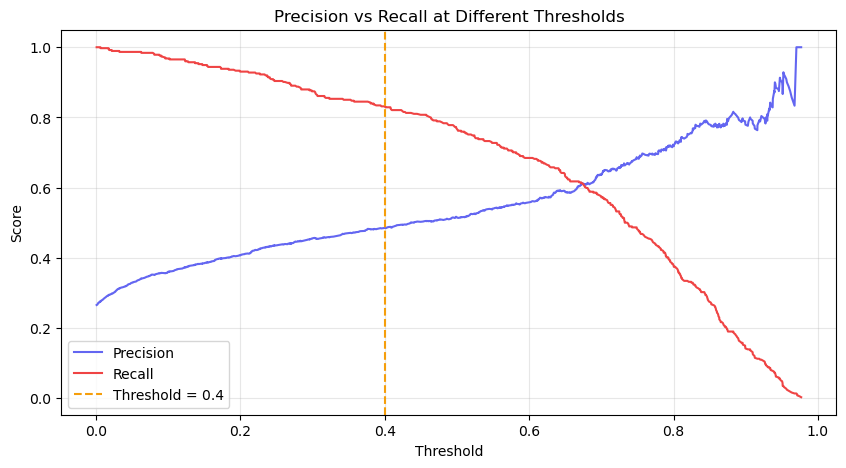

In [20]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(10, 5))

# Plot precision and recall across thresholds
plt.plot(thresholds, precisions[:-1], label='Precision', color='#6366f1')
plt.plot(thresholds, recalls[:-1], label='Recall', color='#ef4444')
plt.axvline(x=0.4, color='#f59e0b', linestyle='--', label='Threshold = 0.4')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [21]:
# Now apply threshold of 0.4 instead of 0.5
y_pred_adjusted = (y_prob_xgb >= 0.4).astype(int)

print("=== XGBoost with Threshold 0.4 ===")
print(classification_report(y_test, y_pred_adjusted))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

=== XGBoost with Threshold 0.4 ===
              precision    recall  f1-score   support

           0       0.92      0.68      0.78      1035
           1       0.49      0.83      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.72      0.74      1409

ROC-AUC: 0.8394


In [24]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save everything the app will need
joblib.dump(xgb, 'models/xgb_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(X.columns.tolist(), 'models/feature_names.pkl')

print("Saved:")
print(" models/xgb_model.pkl")
print(" models/scaler.pkl")
print(" models/feature_names.pkl")

Saved:
 models/xgb_model.pkl
 models/scaler.pkl
 models/feature_names.pkl


In [25]:
# Quick sanity check — reload and predict one row
model_loaded = joblib.load('models/xgb_model.pkl')
test_row = X_test.iloc[[0]]
prob = model_loaded.predict_proba(test_row)[0][1]
print(f"Test prediction probability: {prob:.4f}")
print("Model saved and reloaded successfully ✓")

Test prediction probability: 0.0168
Model saved and reloaded successfully ✓


In [26]:
import shap

# Build SHAP explainer on your XGBoost model
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")  # Should match X_test shape

SHAP values shape: (1409, 22)


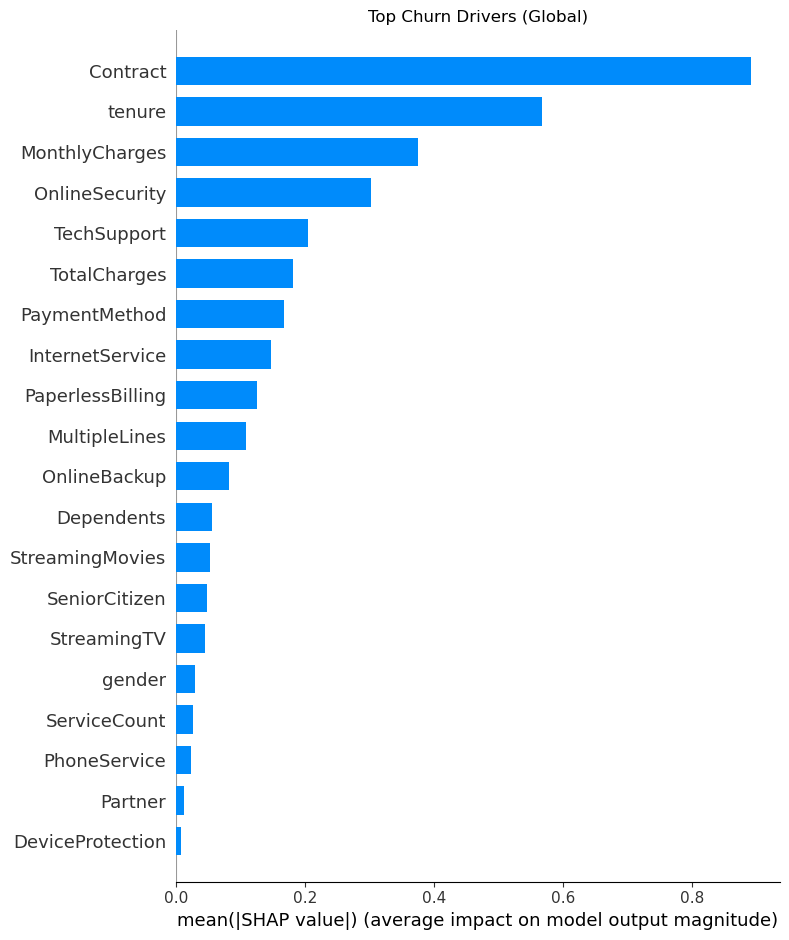

In [27]:
# Global view — which features drive churn the most across ALL customers?
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Top Churn Drivers (Global)")
plt.tight_layout()
plt.savefig('shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

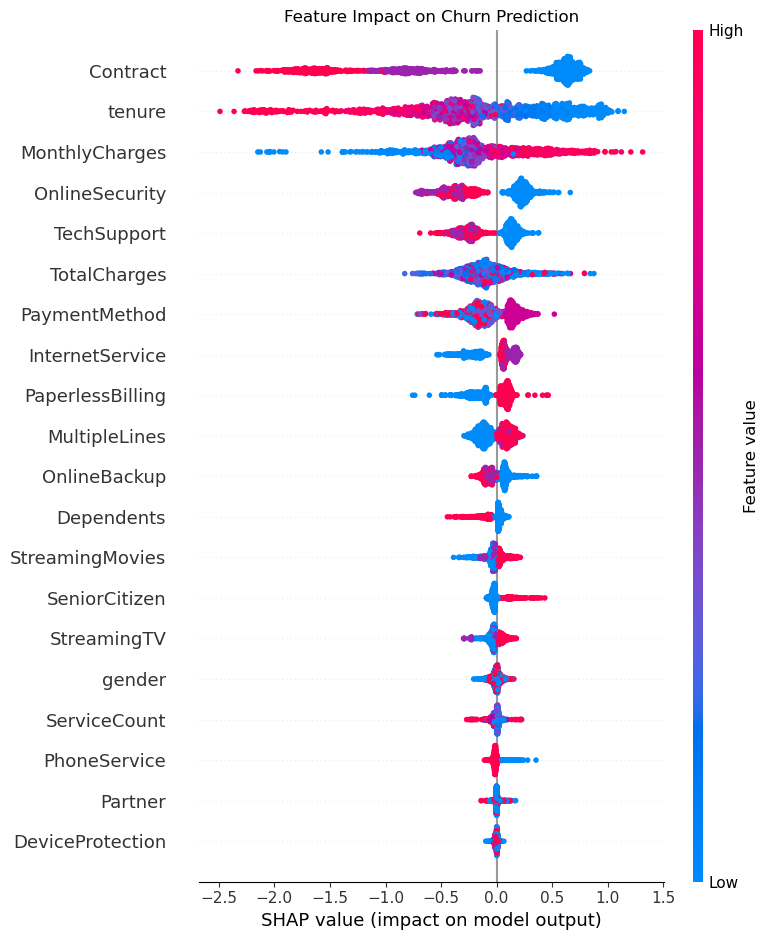

In [28]:
# Detailed view — direction matters here (red = pushes toward churn)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Feature Impact on Churn Prediction")
plt.tight_layout()
plt.savefig('shap_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

Highest risk customer index: 1090
Churn probability: 0.9768


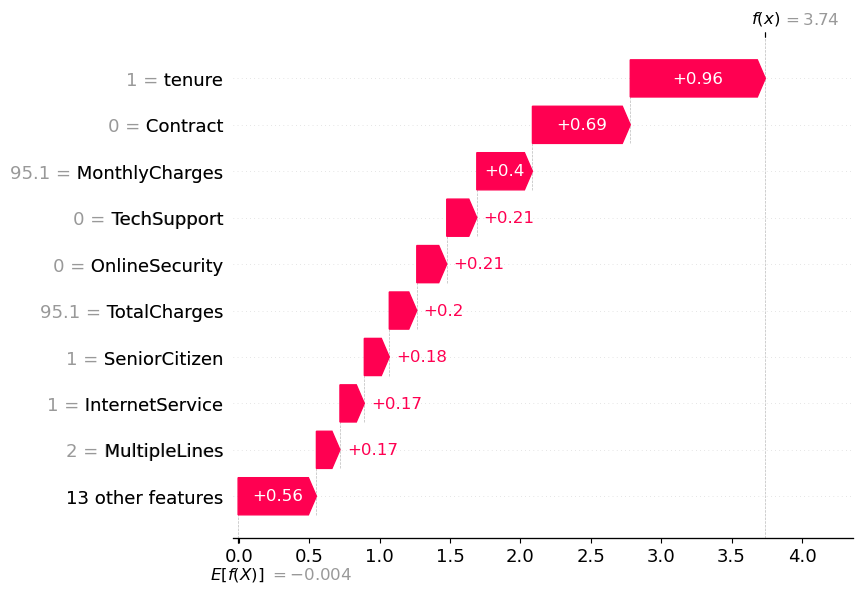

In [29]:
# Individual customer explanation — pick a high-risk customer
# Find someone with high churn probability first
high_risk_idx = y_prob_xgb.argmax()
print(f"Highest risk customer index: {high_risk_idx}")
print(f"Churn probability: {y_prob_xgb[high_risk_idx]:.4f}")

# Show which features pushed this specific customer toward churn
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx],
        feature_names=X.columns.tolist()
    )
)

In [30]:
def get_risk_category(probability):
    if probability < 0.25:
        return "Low Risk", "#22c55e"
    elif probability < 0.50:
        return "Medium Risk", "#f59e0b"
    elif probability < 0.75:
        return "High Risk", "#f97316"
    else:
        return "Critical Risk", "#ef4444"


def get_recommendations(customer, probability):
    """
    Generate personalized retention recommendations
    based on customer profile and churn probability.
    """
    recommendations = []

    if customer['Contract'] == 'Month-to-month':
        recommendations.append({
            'action': 'Upgrade to Annual Contract',
            'reason': 'Month-to-month customers churn at 2x the rate of annual customers',
            'impact': 'High'
        })

    if customer['tenure'] < 12:
        recommendations.append({
            'action': 'Enroll in Onboarding Program',
            'reason': 'First 12 months are the critical retention window',
            'impact': 'High'
        })

    if customer['MonthlyCharges'] > 65:
        recommendations.append({
            'action': 'Offer 15% Loyalty Discount',
            'reason': 'High monthly charges are a top churn driver per SHAP analysis',
            'impact': 'High'
        })

    if customer['TechSupport'] == 'No':
        recommendations.append({
            'action': 'Provide 3 Months Free Tech Support',
            'reason': 'Customers without tech support churn significantly more',
            'impact': 'Medium'
        })

    if customer['ServiceCount'] >= 4:
        recommendations.append({
            'action': 'Offer Bundled Services Discount',
            'reason': 'Customer uses multiple services — bundle pricing increases stickiness',
            'impact': 'Medium'
        })

    if customer['CLV'] > 3000:
        recommendations.append({
            'action': 'Assign Dedicated Account Manager',
            'reason': 'High lifetime value customer — priority retention justified',
            'impact': 'High'
        })

    if not recommendations:
        recommendations.append({
            'action': 'Schedule Quarterly Check-in Call',
            'reason': 'Proactive engagement maintains satisfaction',
            'impact': 'Low'
        })

    return recommendations


def simulate_post_retention_risk(customer, probability, model, feature_names, scaler):
    """
    Simulate churn probability AFTER applying recommendations.
    Shows estimated improvement.
    """
    import pandas as pd
    import numpy as np

    customer_improved = customer.copy()

    # Apply the most impactful interventions
    if customer['Contract'] == 'Month-to-month':
        customer_improved['Contract'] = 'One year'
        customer_improved['ContractRiskScore'] = 2

    if customer['MonthlyCharges'] > 65:
        customer_improved['MonthlyCharges'] = customer['MonthlyCharges'] * 0.85
        customer_improved['CLV'] = customer_improved['MonthlyCharges'] * 24

    if customer['TechSupport'] == 'No':
        customer_improved['TechSupport'] = 'Yes'

    # Re-encode and predict
    from sklearn.preprocessing import LabelEncoder
    row = {}
    for feat in feature_names:
        row[feat] = customer_improved.get(feat, 0)

    df_row = pd.DataFrame([row])

    cat_cols = df_row.select_dtypes(include='object').columns
    for col in cat_cols:
        le = LabelEncoder()
        df_row[col] = le.fit_transform(df_row[col].astype(str))

    new_prob = model.predict_proba(df_row)[0][1]
    improvement = probability - new_prob

    return round(new_prob, 4), round(improvement, 4)

In [31]:
import os
print(os.getcwd())
print(os.listdir('.'))

C:\Users\Rishil\Documents\Customer Churn Prediction
['.ipynb_checkpoints', 'app.py', 'churn_eda.png', 'EDA.ipynb', 'models', 'shap_detailed.png', 'shap_global.png', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [32]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Refit label encoders on the full dataset
df_encode = df.copy()
cat_cols = df_encode.select_dtypes(include='object').columns.tolist()

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(df_encode[col].astype(str))
    label_encoders[col] = le

joblib.dump(label_encoders, 'models/label_encoders.pkl')
print("Saved label_encoders.pkl ✓")
print("Columns encoded:", list(label_encoders.keys()))

Saved label_encoders.pkl ✓
Columns encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
